<a href="https://colab.research.google.com/github/Ravindran-M/img-classify-CNN/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import tensorflow
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

In [59]:
IMG_SIZE=(256,256,3)
premodel=keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=IMG_SIZE,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",


)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [60]:
premodel.trainable=False


premodel.summary()


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 127, 127, 32)   │            864 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 127, 127, 32)   │             96 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 127, 127, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 125, 125, 32)   │          9,216 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 125, 125, 32)   │             96 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 125, 125, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 125, 125, 64)   │         18,432 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 125, 125, 64)   │            192 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 125, 125, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 62, 62, 64)     │              0 │ activation_2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 62, 62, 80)     │          5,120 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 62, 62, 80)     │            240 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 62, 62, 80)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 60, 60, 192)    │        138,240 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 60, 60, 192)    │            576 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

In [61]:
model= keras.Sequential()
model.add(premodel)
model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(256,activation='relu'))
model.add(keras.layers.Dense(4,activation='softmax'))

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)            │ (None, 6, 6, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 73728)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │      18,874,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,678,436 (155.18 MB)

 Trainable params: 18,875,652 (72.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [62]:
(train_ds),(test_ds)= keras.utils.image_dataset_from_directory(
    directory='drive/MyDrive/BrainMRIimage',
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='both',
    seed=42,
    batch_size=32,
    shuffle=True,


)



Found 3096 files belonging to 4 classes.
Using 2477 files for training.
Using 619 files for validation.


In [63]:
import tensorflow as tf
def preprocess(image, label):
  #Casts image to float32 and divides by 255
  image = tf.cast(image, tf.float32)
  image = tf.math.divide(image, 255.0)  # Normalize to [0, 1]
  return image, label

train_ds = train_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

In [64]:
print(train_ds)




<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [65]:
print(len(train_ds))
print(len(test_ds))

78
20


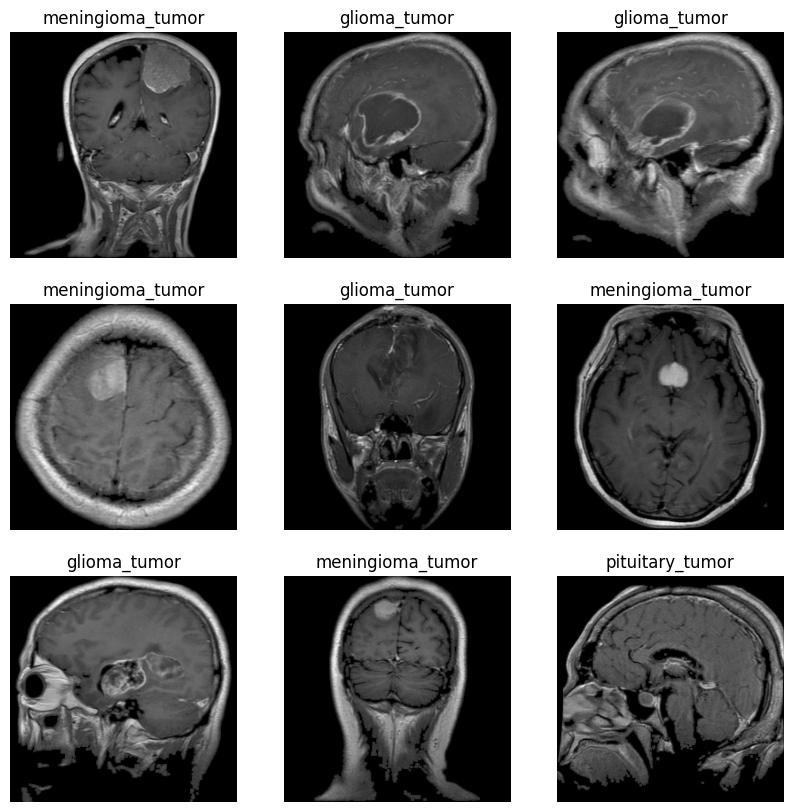

In [66]:


plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())#.astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [67]:
model.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy,
              metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)            │ (None, 6, 6, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 73728)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │      18,874,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,678,436 (155.18 MB)

 Trainable params: 18,875,652 (72.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [68]:
history = model.fit(train_ds, epochs=10, validation_data=(test_ds))

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 647s 8s/step - accuracy: 0.5416 - loss: 14.1687 - val_accuracy: 0.7981 - val_loss: 0.9091
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 645s 8s/step - accuracy: 0.8861 - loss: 0.4569 - val_accuracy: 0.8514 - val_loss: 0.6348
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 572s 7s/step - accuracy: 0.9464 - loss: 0.1694 - val_accuracy: 0.8061 - val_loss: 0.8144
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 581s 7s/step - accuracy: 0.9568 - loss: 0.1184 - val_accuracy: 0.8627 - val_loss: 0.6014
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 580s 7s/step - accuracy: 0.9847 - loss: 0.0490 - val_accuracy: 0.8562 - val_loss: 0.6132
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 583s 7s/step - accuracy: 0.9907 - loss: 0.0206 - val_accuracy: 0.8837 - val_loss: 0.5676
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 651s 8s/step - accuracy: 0.9932 - loss: 0.0185 - val_accuracy: 0.8288 - val_loss: 0.7957
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 585s 7s/step - accuracy: 0.9942 - loss: 0.0145 - val_accuracy: 0.8982 - 

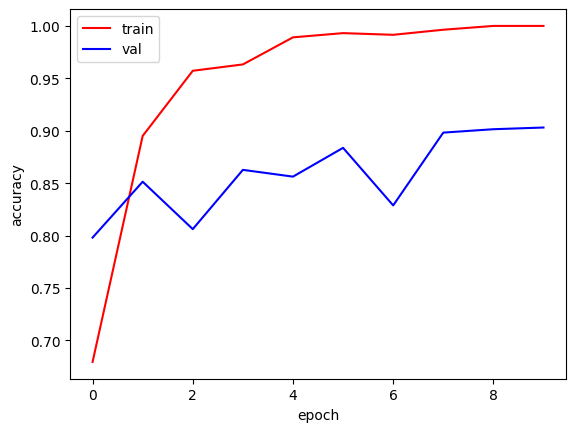

In [69]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='val')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

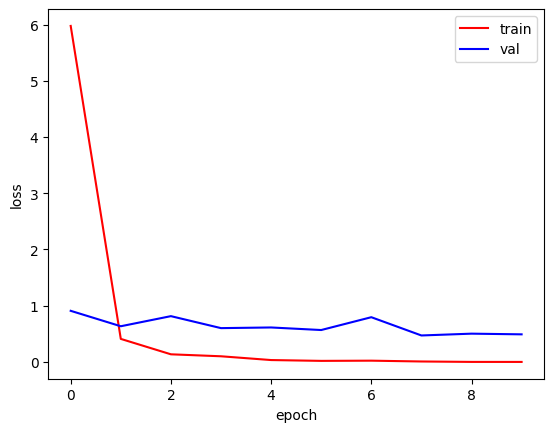

In [70]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [71]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)  # Get predicted labels for all samples
true_labels = []

# Extract true labels from the test dataset
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

accuracy=accuracy_score(true_labels, predicted_labels)
print(f'Accuracy: {accuracy}')
precision = precision_score(true_labels, predicted_labels, average='weighted')
print(f'Precision: {precision}')
recall= recall_score(true_labels, predicted_labels, average='weighted')
print(f'Recall: {recall}')
f1_score= f1_score(true_labels, predicted_labels, average='weighted')
print(f'F1 Score: {f1_score}')
confusion_matrix= confusion_matrix(true_labels, predicted_labels)
print(f'Confusion Matrix:\n{confusion_matrix}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 116s 6s/step
Accuracy: 0.9030694668820679
Precision: 0.9024294556230865
Recall: 0.9030694668820679
F1 Score: 0.9024794494707897
Confusion Matrix:
[[151  16   5   1]
 [ 17 166   0  12]
 [  0   3  69   1]
 [  0   5   0 173]]


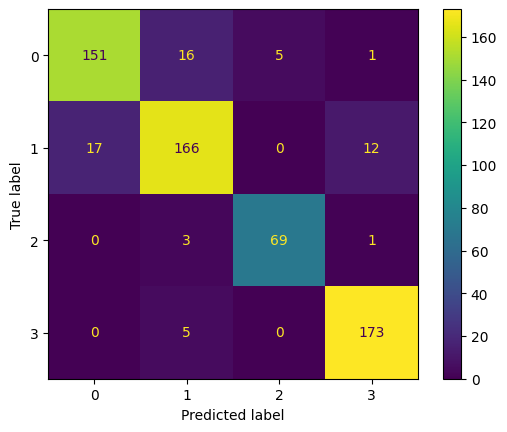

In [72]:
from sklearn import metrics
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
plt.show()

In [73]:
print(predicted_labels)

[0 1 1 0 1 1 1 0 3 3 2 3 2 1 0 0 3 1 3 3 3 1 0 0 3 0 0 3 1 3 3 2 1 1 0 0 1
 0 3 2 1 1 3 3 2 1 1 1 2 3 1 1 3 0 0 0 0 3 3 3 3 1 3 2 1 1 1 3 0 0 1 0 2 3
 3 0 0 3 0 3 2 3 0 1 3 2 0 2 1 2 0 3 3 1 0 3 2 3 1 1 1 3 3 2 1 0 0 1 1 0 0
 2 0 1 3 0 2 1 3 1 0 1 0 1 1 1 3 3 3 3 3 3 1 0 2 0 0 3 3 0 0 1 1 3 3 1 3 1
 2 0 3 1 1 0 3 3 3 3 1 3 1 1 2 1 3 3 1 0 0 3 0 1 0 1 0 0 1 1 3 0 0 3 1 1 2
 1 3 0 0 3 2 1 1 0 0 2 3 3 3 0 0 0 0 1 1 0 0 1 0 1 3 3 3 1 0 2 1 3 3 3 2 1
 0 0 0 2 2 1 1 1 3 2 0 3 0 3 3 0 0 0 3 0 3 1 2 2 0 1 3 0 1 1 3 0 0 0 3 3 1
 0 1 1 2 2 0 3 2 1 3 1 1 1 0 1 0 0 3 3 1 3 3 3 1 3 2 1 0 3 0 0 3 3 0 1 3 0
 2 2 1 3 3 3 2 1 0 0 1 3 1 0 3 0 1 1 3 0 3 1 3 1 0 1 3 3 0 1 2 2 0 3 3 1 0
 1 1 0 0 0 1 2 2 0 1 3 1 2 3 0 3 1 2 0 3 0 3 3 1 0 1 1 2 2 3 1 0 3 3 3 2 0
 2 3 0 1 2 1 3 3 3 0 3 3 0 1 0 2 3 2 0 3 0 0 1 0 0 0 3 1 1 1 3 1 3 1 1 3 1
 0 1 3 0 0 2 0 1 1 3 3 1 2 1 3 1 2 0 0 1 0 0 1 1 0 1 1 1 3 3 1 1 1 2 0 2 1
 1 1 3 3 1 1 0 3 1 3 3 3 2 1 1 3 1 0 1 3 3 3 1 2 1 1 0 3 0 0 3 2 1 3 0 3 0
 0 3 3 1 3 1 3 1 1 3 2 1 

In [74]:
print(true_labels)

[0 1 1 1 0 1 1 0 3 3 2 3 2 1 0 0 3 1 3 3 3 0 0 0 3 0 0 3 1 3 3 2 1 1 0 0 1
 0 3 2 1 1 3 3 2 1 1 1 2 3 1 1 1 1 0 0 0 3 1 3 3 1 1 2 1 1 1 3 0 0 3 0 0 3
 3 0 0 3 0 3 2 3 0 1 3 2 0 2 1 2 0 3 3 1 0 3 2 3 1 1 1 2 3 2 0 0 0 1 1 0 0
 0 0 1 3 0 2 0 3 1 0 3 0 1 1 1 3 3 3 1 3 3 1 0 2 0 0 3 1 0 0 1 1 3 3 1 3 1
 2 0 3 1 1 0 3 3 3 3 1 3 1 1 2 1 1 3 1 1 0 3 0 1 0 1 0 0 0 1 1 0 0 3 1 1 2
 1 3 0 0 3 2 1 1 0 0 0 3 3 3 0 0 0 0 1 0 0 1 1 0 1 3 3 3 1 0 0 1 3 3 3 2 1
 0 0 0 2 2 0 1 1 3 2 1 3 0 3 3 0 0 0 3 0 3 1 2 2 0 1 3 0 0 1 3 0 1 0 3 3 1
 0 3 1 2 2 0 3 2 1 3 0 1 1 0 0 0 0 3 3 1 3 3 3 1 3 2 1 0 3 0 0 3 3 1 1 3 0
 0 2 1 3 3 3 2 1 1 0 1 3 3 0 3 1 1 1 3 1 3 1 3 1 0 1 1 3 0 2 2 2 0 3 3 0 0
 1 1 1 0 0 1 2 2 0 1 3 1 2 3 0 3 1 2 0 3 0 3 3 1 0 1 1 2 2 3 1 0 3 3 3 2 0
 2 1 0 1 2 1 3 3 3 0 1 3 0 1 0 2 3 2 0 3 0 0 0 0 0 0 3 1 1 1 3 1 3 1 1 3 1
 0 1 3 0 0 2 0 1 1 3 3 1 2 1 3 1 2 0 0 1 0 0 1 1 0 1 1 1 3 3 1 1 1 2 1 2 1
 1 1 3 3 1 1 0 3 1 3 3 3 2 1 1 3 1 0 1 3 3 3 1 2 0 1 0 3 0 1 3 2 1 0 0 3 0
 0 3 3 1 3 1 3 1 1 3 2 3 